# M1.Ex1: Model Hours vs Marks

### Name: Shaima alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [56]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [57]:
df = pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()


,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [58]:
X = df[["Hours_Studied"]]   # feature
y = df["Marks"]             # target


### Step 2.b print the type of each

In [59]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [60]:
print("Target type: numerical (continuous)")
print("Task type: regression")

Target type: numerical (continuous)
Task type: regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)  

X shape: (100, 1)
y shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [62]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

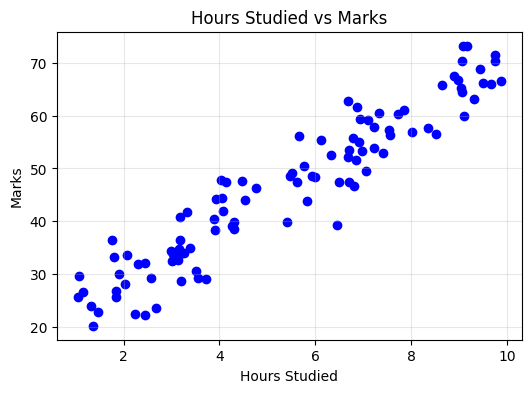

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["Hours_Studied"], df["Marks"], color="blue")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks")
plt.grid(True, alpha=0.3)
plt.show()


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [64]:
print("The relationship between Hours_Studied and Marks is increasing (positive correlation).")

The relationship between Hours_Studied and Marks is increasing (positive correlation).


### Step 7. Initialize a `LinearRegression` model

In [65]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (80, 1)
X_test shape: (20, 1)
y_train shape: (80,)
y_test shape: (20,)


### Step 9.a Train the model on the training set

In [67]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [68]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope (a):", slope)
print("Intercept (b):", intercept)
print(f"Model equation: y = {slope:.3f} * x + {intercept:.3f}")

Slope (a): 5.164438413499556
Intercept (b): 18.538578512317276
Model equation: y = 5.164 * x + 18.539


### Step 9.c how much marks do we get per 1 hour of study?

In [69]:
print(f"For each additional 1 hour of study, marks increase by about {slope:.2f} marks.")

For each additional 1 hour of study, marks increase by about 5.16 marks.


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [70]:
ten_minutes_in_hours = 10 / 60
marks_for_10_min = slope * ten_minutes_in_hours
print(f"For an extra 10 minutes of study, marks increase by about {marks_for_10_min:.2f} marks.")

For an extra 10 minutes of study, marks increase by about 0.86 marks.


### Step 9.e if one doesn't study at all, how much marks do they get?

In [71]:
marks_if_zero_hours = intercept
print(f"If a student doesn't study at all (0 hours), predicted marks = {marks_if_zero_hours:.2f}")

If a student doesn't study at all (0 hours), predicted marks = 18.54


### Step 10. Evaluate the model on the test set

In [73]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_test = model.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5

print("R^2 on test set:", r2)
print("MSE on test set:", mse)
print("RMSE on test set:", rmse)


R^2 on test set: 0.9258085525213727
MSE on test set: 14.731128407667583
RMSE on test set: 3.838115215528005


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [ ]:
sample_X = X_test.head(3)
sample_y_true = y_test.head(3)
sample_y_pred = model.predict(sample_X)

print("Sample rows from test set:")
for i in range(len(sample_X)):
    hours = sample_X.iloc[i, 0]
    true_mark = sample_y_true.iloc[i]
    pred_mark = sample_y_pred[i]
    print(f"Hours: {hours}, True Marks: {true_mark}, Predicted Marks: {pred_mark:.2f}")


Sample rows from test set:
Hours: 3.02, True Marks: 32.5, Predicted Marks: 34.14
Hours: 8.9, True Marks: 67.54, Predicted Marks: 64.50
Hours: 6.78, True Marks: 55.7, Predicted Marks: 53.55


### Step 12. Plot the data and the regression line

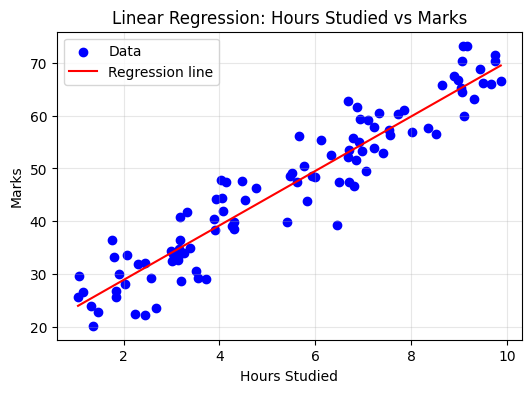

In [76]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, color="blue", label="Data")

x_line = pd.DataFrame({"Hours_Studied": sorted(X["Hours_Studied"])})
y_line = model.predict(x_line)
plt.plot(x_line["Hours_Studied"], y_line, color="red", label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Linear Regression: Hours Studied vs Marks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
